In [1]:
import numpy as np


class PCA:
    def __init__(self, n_components: int | None = None):
        self.n_components = n_components

        self.mean_ = None
        self.scale_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.n_features_in_ = None

    def fit(self, X: np.ndarray) -> None:
        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        if np.isnan(X).any():
            raise ValueError("X must not contain NaN values.")

        n, p = X.shape

        if n < 2:
            raise ValueError("At least two observations are required.")

        if self.n_components is not None:
            if self.n_components <= 0:
                raise ValueError("n_components must be strictly positive.")
            if self.n_components > p:
                raise ValueError(
                    "n_components cannot be greater than the number of features."
                )

        self.n_features_in_ = p

        # Centering
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        # Scaling using the empirical standard deviation
        self.scale_ = np.sqrt(
            np.sum(X_centered**2, axis=0) / (n - 1)
        )

        if np.any(self.scale_ == 0):
            raise ValueError("X contains at least one constant feature.")

        X_std = X_centered / self.scale_

        # Correlation matrix
        cov_matrix = X_std.T @ X_std / (n - 1)

        # Spectral decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Descending order
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        # Explained variance ratio must use ALL eigenvalues
        total_variance = eigenvalues.sum()
        explained_variance_ratio = eigenvalues / total_variance

        # Number of retained components
        k = p if self.n_components is None else self.n_components

        self.components_ = eigenvectors[:, :k]
        self.explained_variance_ = eigenvalues[:k]
        self.explained_variance_ratio_ = explained_variance_ratio[:k]

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.components_ is None:
            raise RuntimeError("PCA must be fitted before calling transform().")

        if X.ndim != 2:
            raise ValueError("X must be a 2D array.")

        if X.shape[1] != self.n_features_in_:
            raise ValueError(
                f"Expected {self.n_features_in_} features, "
                f"got {X.shape[1]}."
            )

        X_std = (X - self.mean_) / self.scale_

        return X_std @ self.components_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        self.fit(X)
        return self.transform(X)

In [2]:
# Donnée de tests
import numpy as np

rng = np.random.default_rng(42)

n = 500

x1 = rng.normal(0, 3, n)
x2 = 0.8 * x1 + rng.normal(0, 1, n)
x3 = -0.4 * x1 + 0.7 * x2 + rng.normal(0, 0.5, n)

X = np.column_stack([x1, x2, x3])

In [3]:
pca = PCA(n_components=2)
Z = pca.fit_transform(X)

Text(0, 0.5, 'PC2')

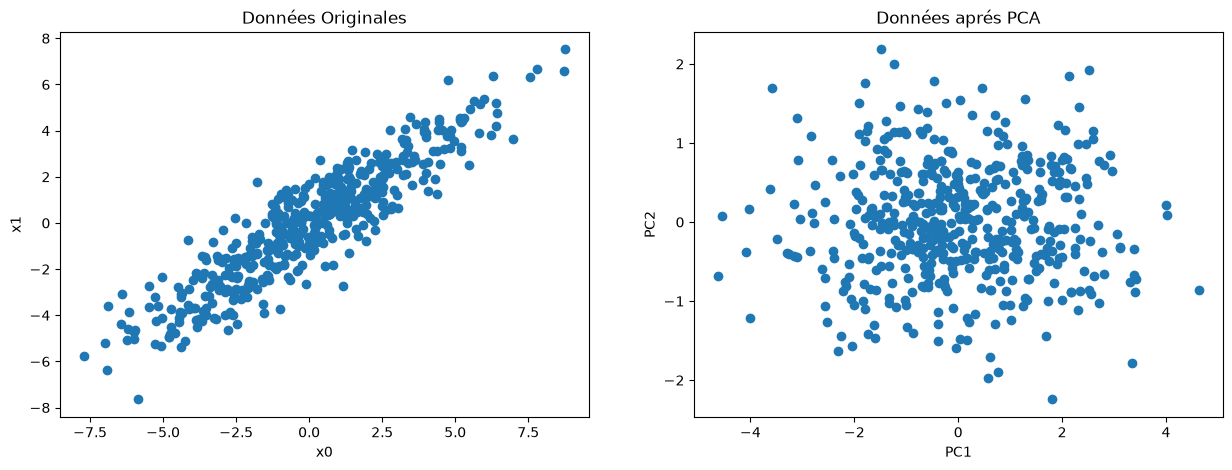

In [9]:
# Quelques graphiques
## scatter plot
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(15,5))

axs[0].scatter(X[:, 0], X[:,1])
axs[0].set_title("Données Originales")
axs[0].set_xlabel("x0")
axs[0].set_ylabel("x1")

axs[1].scatter(Z[:,0], Z[:, 1])
axs[1].set_title("Données aprés PCA")
axs[1].set_xlabel("PC1")
axs[1].set_ylabel("PC2")